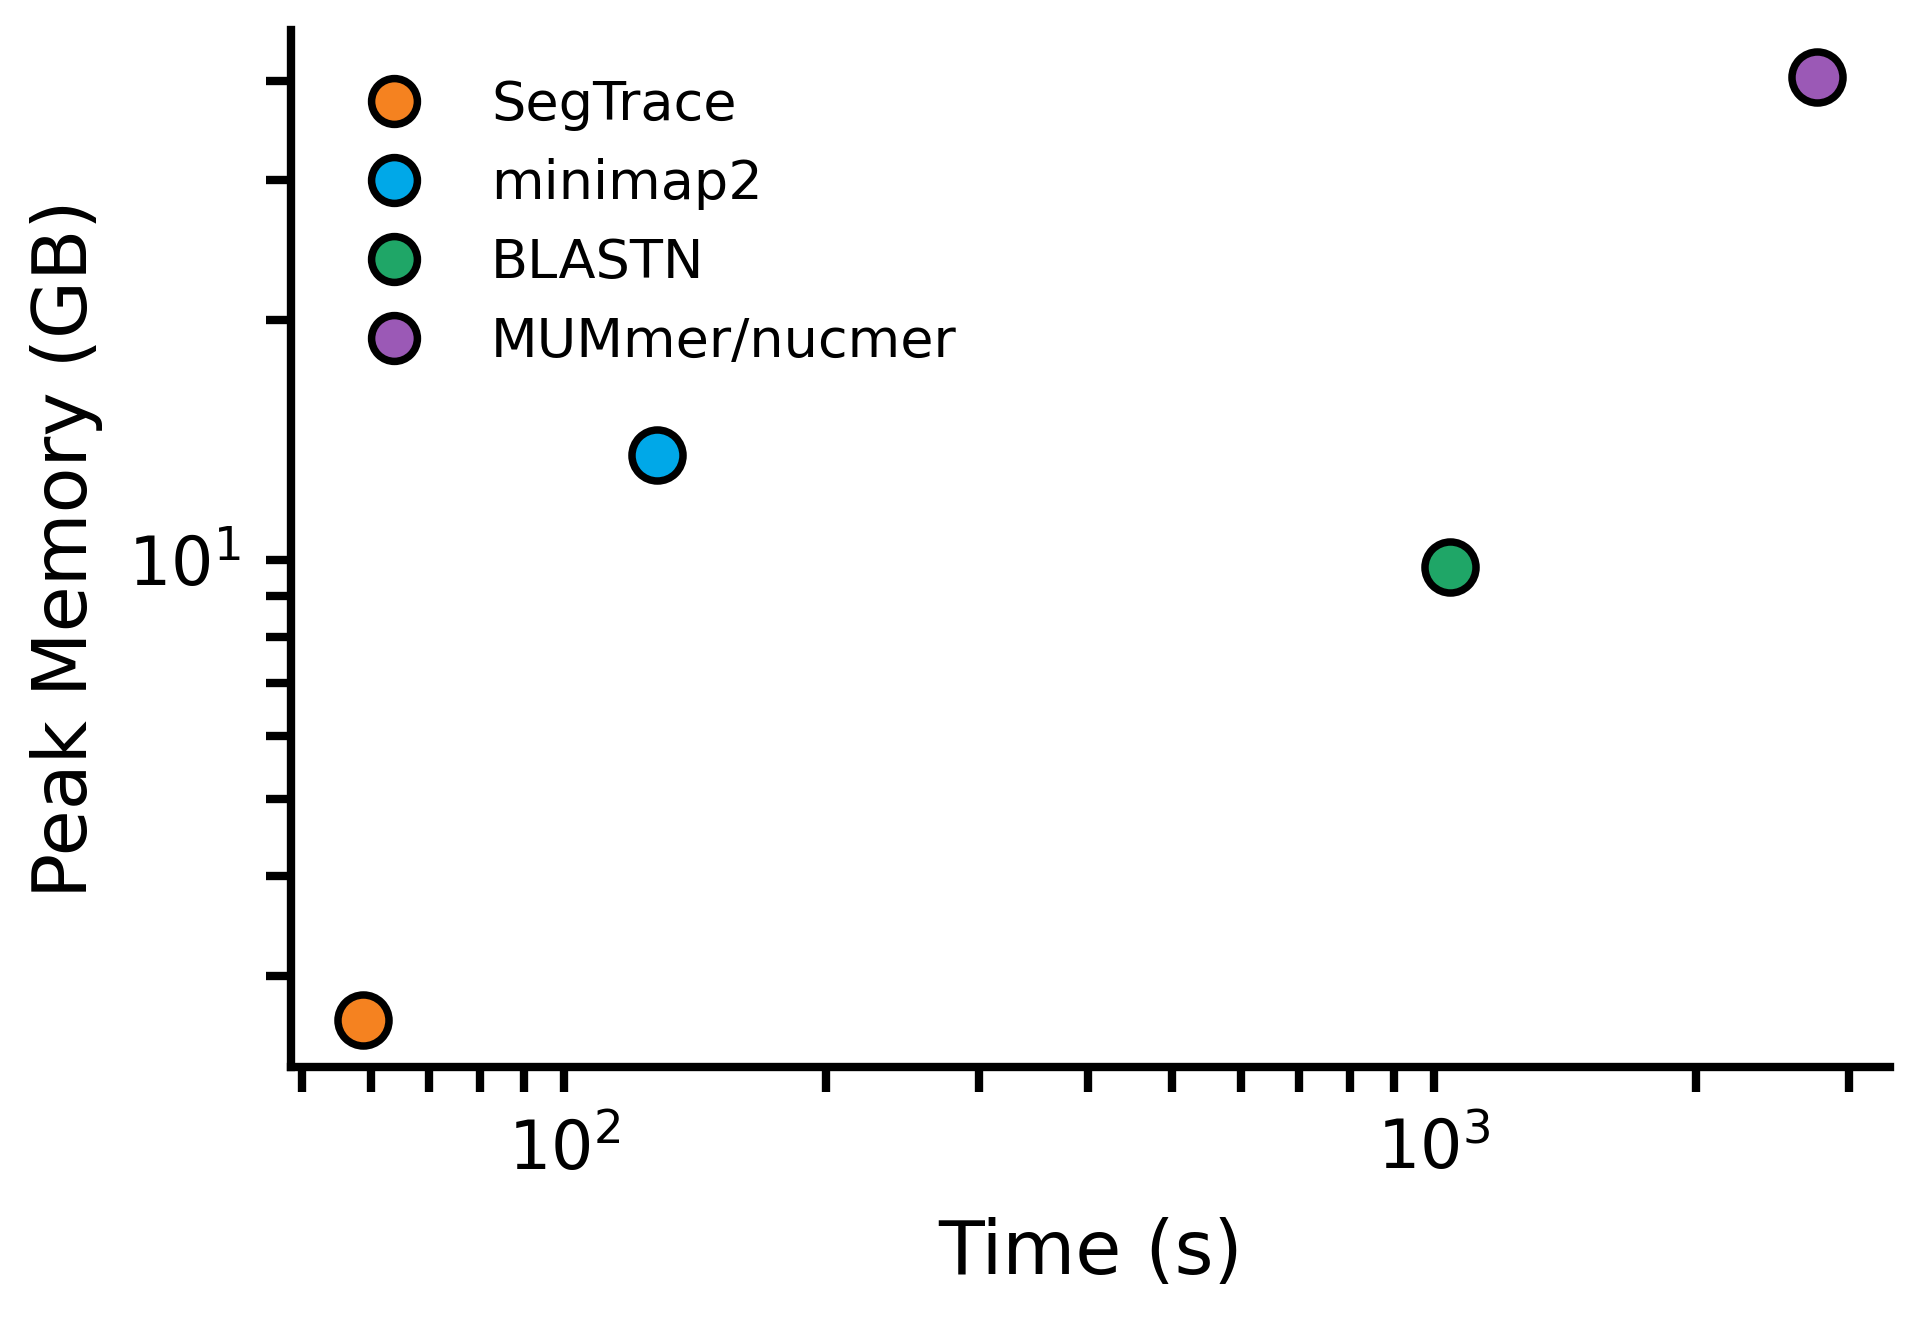

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

plt.rcParams['svg.fonttype'] = 'none'

df = pd.read_csv('benchmark_results.csv')
bench = df[df['tool'] != 'Truth'].copy()
bench['max_rss_gb'] = bench['max_rss_kb'] / (1024 * 1024)

tool_colors = {
    'SegTrace': '#f58220',      # Orange
    'minimap2': '#00a8e8',      # Sky Blue
    'BLASTN': '#1fa667',        # Green
    'MUMmer/nucmer': '#9b59b6'   # Purple
}

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=300)

for _, row in bench.iterrows():
    tool = row['tool']
    color = tool_colors.get(tool, 'gray')

    ax.scatter(
        row['time_perf_seconds'],
        row['max_rss_gb'],
        marker='o',
        facecolor=color,
        edgecolor='black',
        linewidth=1.8,
        s=150,
        zorder=3
    )

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Time (s)', fontsize=18, labelpad=8)
ax.set_ylabel('Peak Memory (GB)', fontsize=18, labelpad=6)

for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2.0)
    ax.spines[spine].set_color('black')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis='both', which='both', direction='out', length=6, width=2.0, color='black', pad=6)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

legend_elements = [
    Line2D([0], [0], marker='o', color='none', markeredgecolor='black', markerfacecolor=tool_colors[t],
           markersize=11, markeredgewidth=1.8, label=t) for t in ['SegTrace', 'minimap2', 'BLASTN', 'MUMmer/nucmer']
]

ax.legend(
    handles=legend_elements,
    loc='upper left',
    frameon=False,
    fontsize=13
)

plt.tight_layout()
plt.savefig('time_log_memory.svg')
plt.show()

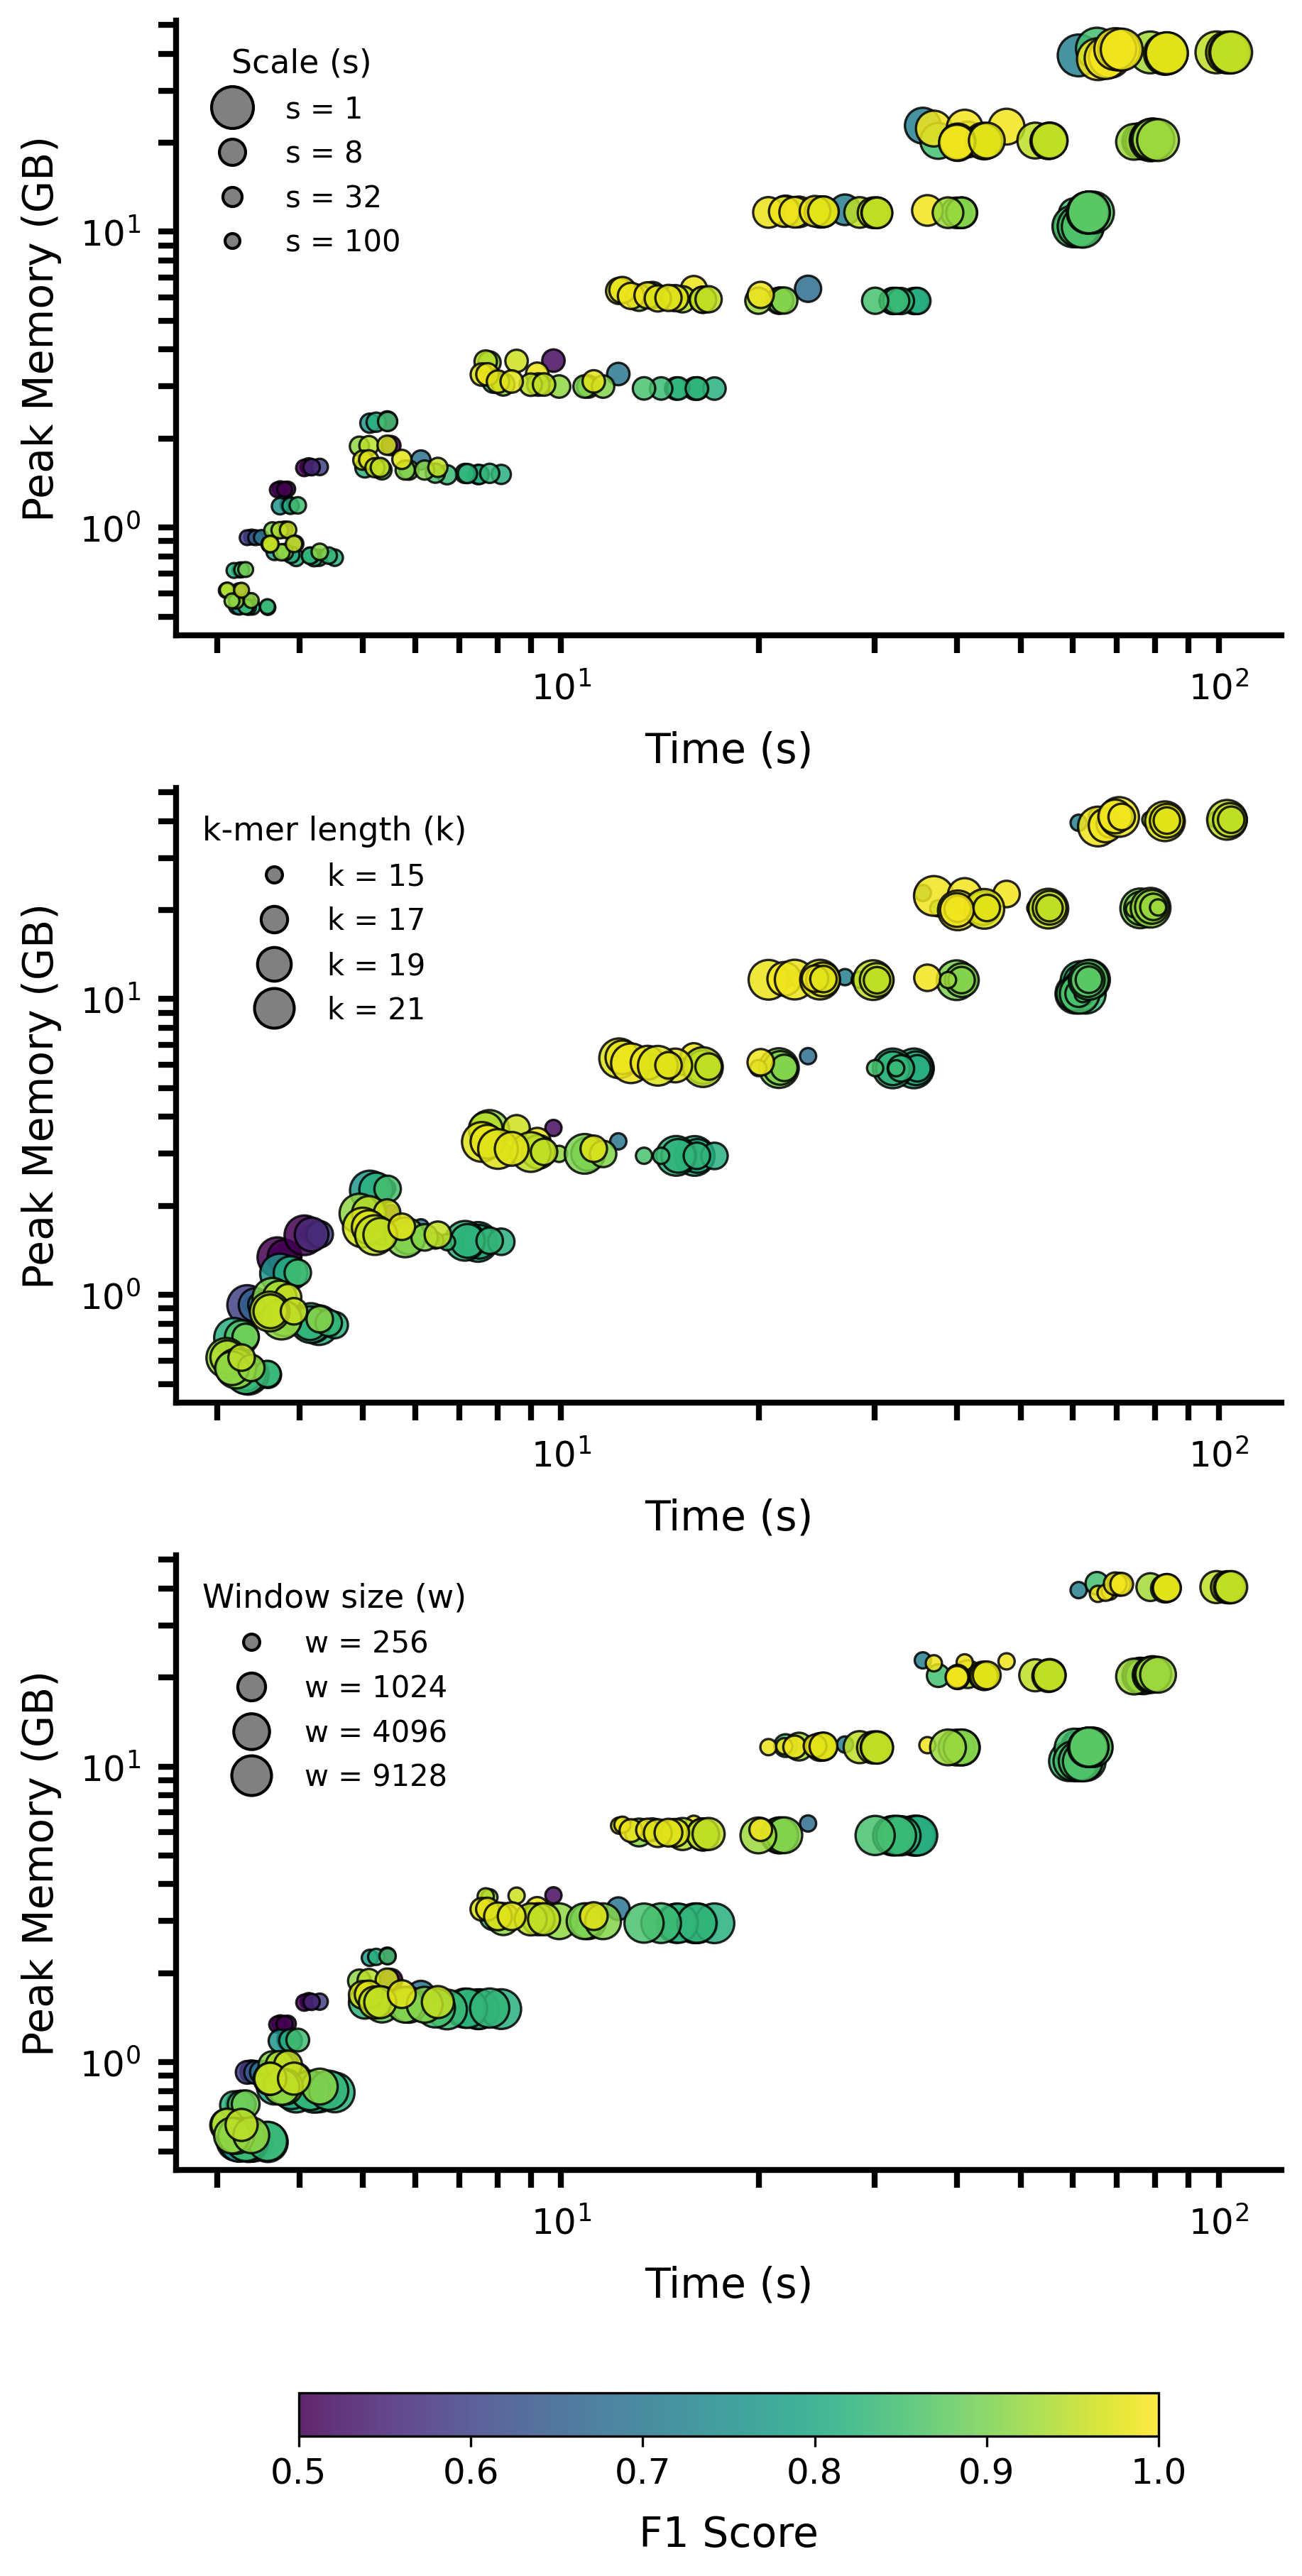

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

plt.rcParams['svg.fonttype'] = 'none'

# 데이터 로드 및 단위 변환 (KB -> GB)
df = pd.read_csv('parameter_sweep.csv')
df['max_rss_gb'] = df['max_rss_kb'] / (1024 * 1024)

# F1 점수가 높은 점이 위에 오도록 정렬
df_sorted = df.sort_values('frag_f1')

# 파라미터별 원 크기 스케일링 설정
sizes_s = 200 / (df_sorted['s'] ** 0.45)
sizes_k = 30 + (df_sorted['k'] - 15) / (21 - 15) * 150
sizes_w = 30 + (np.log2(df_sorted['w']) - np.log2(256)) / (np.log2(9128) - np.log2(256)) * 150

# 3행 1열의 세로로 긴 레이아웃 생성
fig, axes = plt.subplots(3, 1, figsize=(6, 12), dpi=300, layout='constrained')

panel_configs = [
    (sizes_s, 's', [1, 8, 32, 100], lambda x: 200 / (x ** 0.45), 'Scale (s)'),
    (sizes_k, 'k', [15, 17, 19, 21], lambda x: 30 + (x - 15) / 6 * 150, 'k-mer length (k)'),
    (sizes_w, 'w', [256, 1024, 4096, 9128],
     lambda x: 30 + (np.log2(x) - np.log2(256)) / (np.log2(9128) - np.log2(256)) * 150, 'Window size (w)')
]

for idx, (sizes, col, samples, formula, legend_title) in enumerate(panel_configs):
    ax = axes[idx]

    sc = ax.scatter(
        df_sorted['time_perf_seconds'],
        df_sorted['max_rss_gb'],
        c=df_sorted['bp_f1'],
        cmap='viridis',
        vmin=0.5,
        vmax=1.0,
        marker='o',
        edgecolor='black',
        linewidth=0.8,
        s=sizes,
        alpha=0.85,
        zorder=3
    )

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel('Time (s)', fontsize=14, labelpad=8)
    ax.set_ylabel('Peak Memory (GB)', fontsize=14, labelpad=6)

    # 축 스파인 설정
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(2.0)
        ax.spines[spine].set_color('black')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    # 눈금 설정
    ax.tick_params(axis='both', which='both', direction='out', length=6, width=2.0, color='black', pad=6)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # 원 크기 범례
    legend_handles = [
        Line2D([0], [0], marker='o', color='none', markeredgecolor='black', markerfacecolor='gray',
               markersize=np.sqrt(formula(val)), label=f'{col} = {val}')
        for val in samples
    ]

    ax.legend(
        handles=legend_handles,
        title=legend_title,
        title_fontsize=11,
        loc='upper left',
        frameon=False,
        fontsize=10
    )

# 공통 컬러바 설정
cbar = fig.colorbar(sc, ax=axes, orientation='horizontal', fraction=0.02, pad=0.04)
cbar.set_label('F1 Score', fontsize=14, labelpad=8)
cbar.ax.tick_params(labelsize=12)

plt.savefig('parameter_sweep.svg')
plt.show()

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


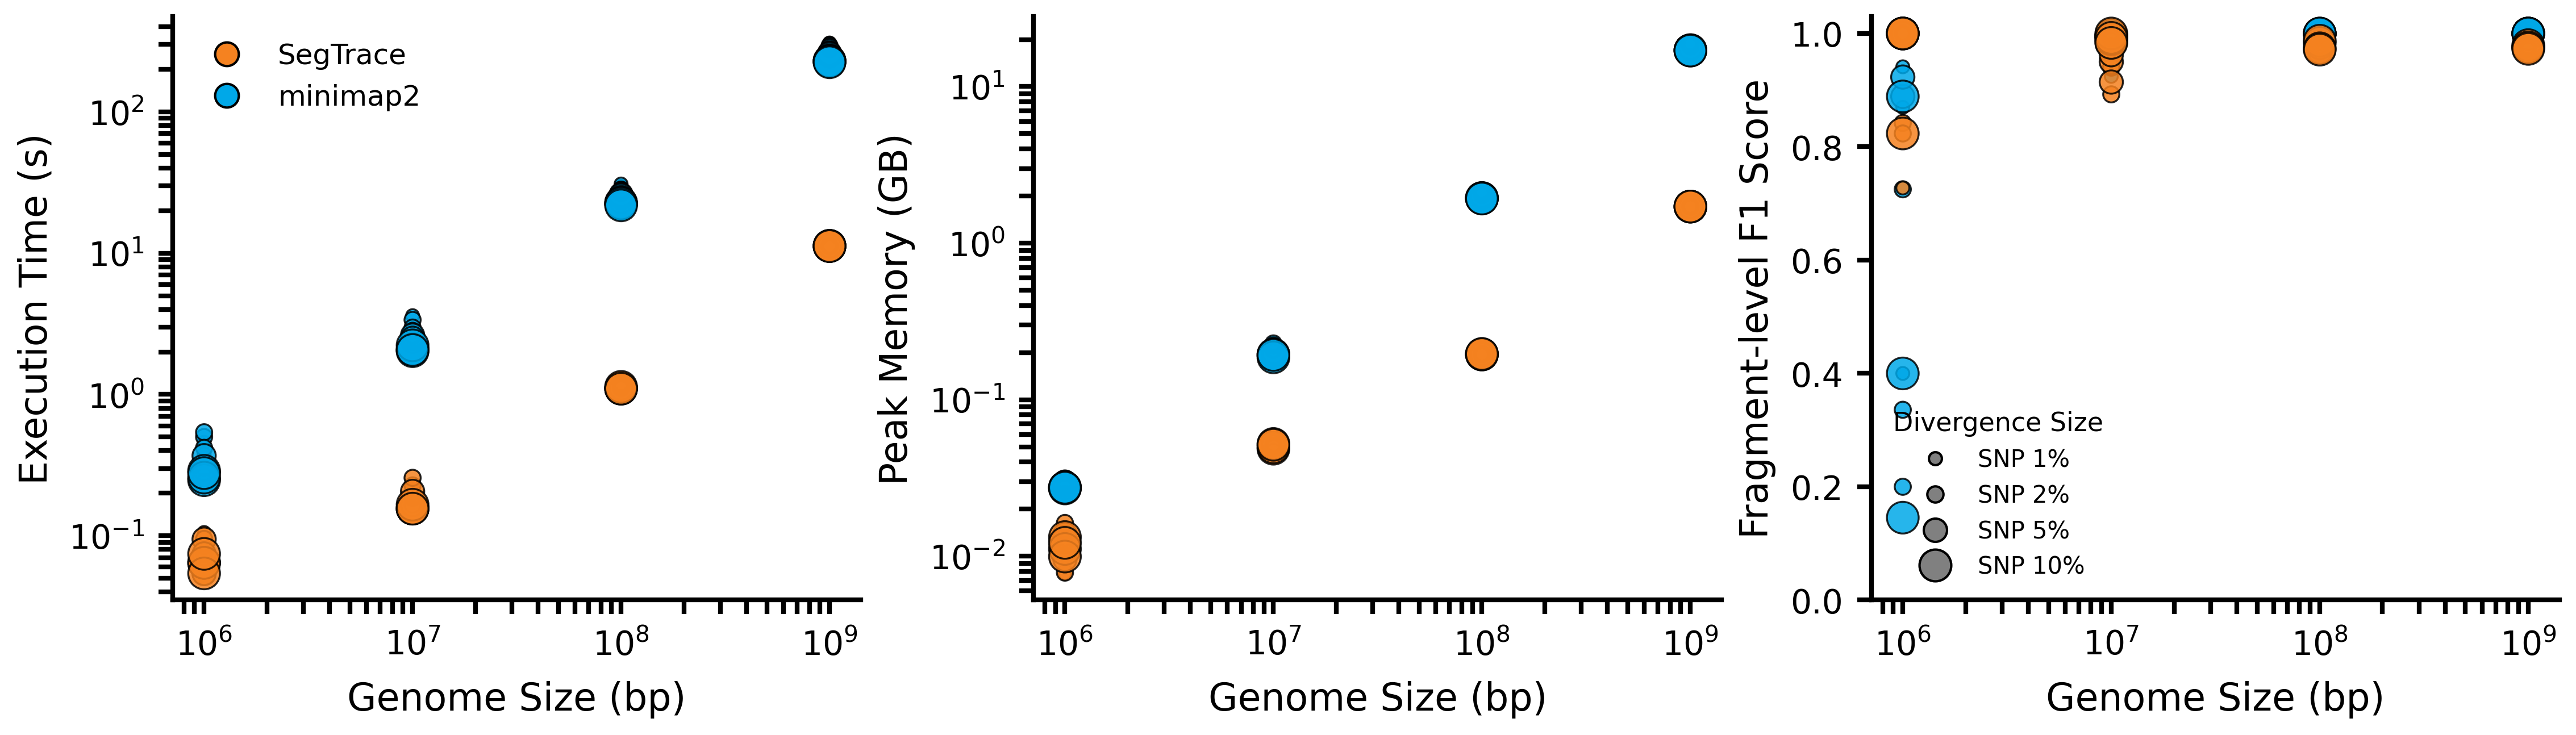

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

plt.rcParams['svg.fonttype'] = 'none'

# 데이터 로드 및 단위 변환 (KB -> GB)
df = pd.read_csv('./drive/MyDrive/Data/simulation_sweep.csv')
df['max_rss_gb'] = df['max_rss_kb'] / (1024 * 1024)

# 도구별 색상 지정 (SegTrace: 주황색, minimap2: 하늘색)
tool_colors = {
    'SegTrace': '#f58220',
    'minimap2': '#00a8e8'
}

# 1행 3열 가로 스케일 레이아웃 생성
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), dpi=300, layout='constrained')

# 각 패널별 측정 항목 (1: Execution Time, 2: Peak Memory, 3: F1 Score)
panel_configs = [
    ('time_perf_seconds', 'Execution Time (s)', True, 'upper left'),
    ('max_rss_gb', 'Peak Memory (GB)', True, 'upper left'),
    ('frag_f1', 'Fragment-level F1 Score', False, 'lower left')
]

# 점 크기 스케일링 (SNP % 변이율 반영: 1% ~ 10%)
df['snp_marker_size'] = 30 + (df['snp_percent'] - 1) / 9 * 150

for idx, (y_col, y_label, is_log, legend_loc) in enumerate(panel_configs):
    ax = axes[idx]

    # minimap2를 먼저 그리고 SegTrace를 나중에 렌더링하여 SegTrace 점이 전면에 표출되도록 설정
    for tool in ['minimap2', 'SegTrace']:
        sub = df[df['tool'] == tool]
        ax.scatter(
            sub['genome_bp'],
            sub[y_col],
            color=tool_colors[tool],
            marker='o',
            edgecolor='black',
            linewidth=0.8,
            s=sub['snp_marker_size'],
            alpha=0.85,
            zorder=4 if tool == 'SegTrace' else 3,
            label=tool
        )

    ax.set_xscale('log')
    if is_log:
        ax.set_yscale('log')

    ax.set_xlabel('Genome Size (bp)', fontsize=16, labelpad=8)
    ax.set_ylabel(y_label, fontsize=16, labelpad=6)

    if y_col == 'frag_f1':
        ax.set_ylim(0.0, 1.03)

    # 축 스파인 설정 (굵은 외곽선)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(2.0)
        ax.spines[spine].set_color('black')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    # 눈금 설정
    ax.tick_params(axis='both', which='both', direction='out', length=6, width=2.0, color='black', pad=6)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # 패널별 범례 구성
    if idx == 0:
        tool_handles = [
            Line2D([0], [0], marker='o', color='none', markeredgecolor='black',
                   markerfacecolor=tool_colors[t], markersize=10, label=t)
            for t in ['SegTrace', 'minimap2']
        ]
        ax.legend(handles=tool_handles, loc=legend_loc, frameon=False, fontsize=12)

    if idx == 2:
        snp_samples = [1, 2, 5, 10]
        snp_handles = [
            Line2D([0], [0], marker='o', color='none', markeredgecolor='black', markerfacecolor='gray',
                   markersize=np.sqrt(30 + (v - 1) / 9 * 150), label=f'SNP {v}%')
            for v in snp_samples
        ]
        ax.legend(handles=snp_handles, title='Divergence Size', title_fontsize=11,
                  loc=legend_loc, frameon=False, fontsize=10)

plt.savefig('simulation_sweep.svg')
plt.show()